In [1]:
# ============================================================
# CODSOFT TASK 2 - CREDIT CARD FRAUD DETECTION
# Step 1: Import Required Libraries
# ============================================================

import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# Step 2: Extract Dataset
# ============================================================

ZIP_PATH = "../archive.zip"
EXTRACT_PATH = "../data"

os.makedirs(EXTRACT_PATH, exist_ok=True)

if not os.path.exists(os.path.join(EXTRACT_PATH, "fraudTrain.csv")):
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [3]:
# ============================================================
# Step 3: Check Dataset Files
# ============================================================

for root, dirs, files in os.walk(EXTRACT_PATH):
    for file in files:
        print(os.path.join(root, file))

../data\fraudTest.csv
../data\fraudTrain.csv


In [4]:
# ============================================================
# Step 4: Load Dataset
# ============================================================

TRAIN_PATH = "../data/fraudTrain.csv"
TEST_PATH = "../data/fraudTest.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training dataset loaded!")
print("Testing dataset loaded!")

Training dataset loaded!
Testing dataset loaded!


In [5]:
# ============================================================
# Step 5: Basic Dataset Information
# ============================================================

print("TRAINING DATASET")
print("=" * 50)

print("Shape:", train_df.shape)
print("\nColumns:")
print(train_df.columns.tolist())

print("\nData Types:")
print(train_df.dtypes)

print("\nFirst 5 Rows:")
display(train_df.head())

TRAINING DATASET
Shape: (1296675, 23)

Columns:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Data Types:
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float6

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
# ============================================================
# Step 6: Testing Dataset Information
# ============================================================

print("TESTING DATASET")
print("=" * 50)

print("Shape:", test_df.shape)

print("\nFirst 5 Rows:")
display(test_df.head())

TESTING DATASET
Shape: (555719, 23)

First 5 Rows:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [7]:
# ============================================================
# Step 7: Missing Values
# ============================================================

missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

if len(missing_values) == 0:
    print("No missing values found in the training dataset.")
else:
    print("Columns containing missing values:")
    display(missing_values)

No missing values found in the training dataset.


In [8]:
# ============================================================
# Step 8: Fraud Distribution
# ============================================================

print("Target Variable: is_fraud")
print("=" * 50)

print(train_df["is_fraud"].value_counts())

print("\nPercentage Distribution:")
print(
    train_df["is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target Variable: is_fraud
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage Distribution:
is_fraud
0    99.42
1     0.58
Name: proportion, dtype: float64


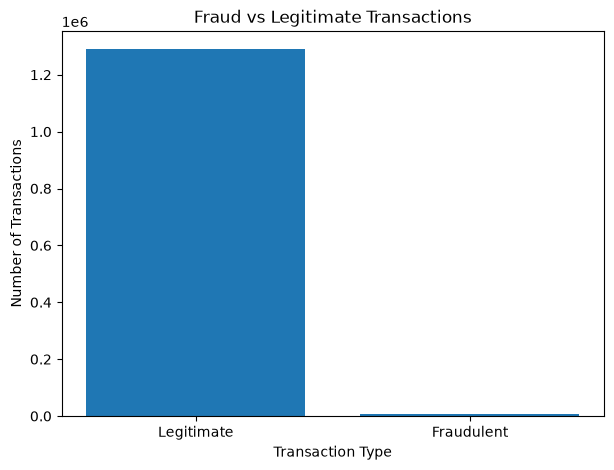

In [9]:
# ============================================================
# Step 9: Fraud vs Legitimate Transactions
# ============================================================

fraud_counts = train_df["is_fraud"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Legitimate", "Fraudulent"],
    fraud_counts.reindex([0, 1])
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

In [10]:
# ============================================================
# Step 10: Numerical Summary
# ============================================================

display(train_df.describe())

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [11]:
# ============================================================
# Step 11: Inspect All Features
# ============================================================

print("Number of columns:", len(train_df.columns))
print("\nColumns:")
for i, column in enumerate(train_df.columns, start=1):
    print(f"{i:2}. {column}")

Number of columns: 23

Columns:
 1. Unnamed: 0
 2. trans_date_trans_time
 3. cc_num
 4. merchant
 5. category
 6. amt
 7. first
 8. last
 9. gender
10. street
11. city
12. state
13. zip
14. lat
15. long
16. city_pop
17. job
18. dob
19. trans_num
20. unix_time
21. merch_lat
22. merch_long
23. is_fraud


In [12]:
# ============================================================
# Step 12: Fraud Percentage
# ============================================================

total_transactions = len(train_df)
fraud_transactions = train_df["is_fraud"].sum()
legitimate_transactions = total_transactions - fraud_transactions

fraud_percentage = (fraud_transactions / total_transactions) * 100
legitimate_percentage = (legitimate_transactions / total_transactions) * 100

print(f"Total transactions     : {total_transactions:,}")
print(f"Legitimate transactions: {legitimate_transactions:,}")
print(f"Fraudulent transactions: {fraud_transactions:,}")
print(f"\nLegitimate percentage  : {legitimate_percentage:.4f}%")
print(f"Fraud percentage       : {fraud_percentage:.4f}%")

Total transactions     : 1,296,675
Legitimate transactions: 1,289,169
Fraudulent transactions: 7,506

Legitimate percentage  : 99.4211%
Fraud percentage       : 0.5789%


In [13]:
# ============================================================
# Step 13: Transaction Amount Analysis
# ============================================================

amount_summary = train_df.groupby("is_fraud")["amt"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

amount_summary.index = ["Legitimate", "Fraudulent"]

display(amount_summary)

,count,mean,median,min,max,std
Legitimate,1289169,67.667110,47.280,1.00,28948.90,154.007971
Fraudulent,7506,531.320092,396.505,1.06,1376.04,390.560070


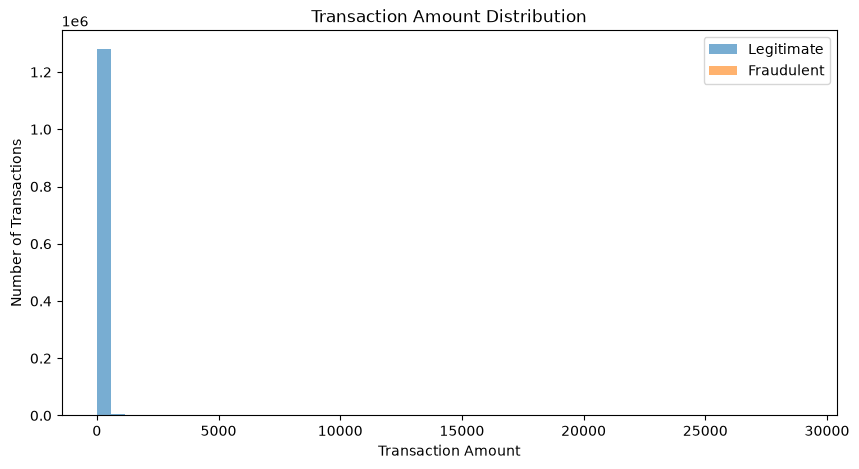

In [14]:
# ============================================================
# Step 14: Amount Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    train_df.loc[train_df["is_fraud"] == 0, "amt"],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    train_df.loc[train_df["is_fraud"] == 1, "amt"],
    bins=50,
    alpha=0.6,
    label="Fraudulent"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")
plt.legend()

plt.show()

In [15]:
# ============================================================
# Step 15: Convert Transaction Time
# ============================================================

train_df["trans_date_trans_time"] = pd.to_datetime(
    train_df["trans_date_trans_time"]
)

test_df["trans_date_trans_time"] = pd.to_datetime(
    test_df["trans_date_trans_time"]
)

print(train_df["trans_date_trans_time"].head())

0   2019-01-01 00:00:18
1   2019-01-01 00:00:44
2   2019-01-01 00:00:51
3   2019-01-01 00:01:16
4   2019-01-01 00:03:06
Name: trans_date_trans_time, dtype: datetime64[us]


In [16]:
# ============================================================
# Step 16: Time-Based Feature Engineering
# ============================================================

for df in [train_df, test_df]:
    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
    df["transaction_day"] = df["trans_date_trans_time"].dt.day
    df["transaction_month"] = df["trans_date_trans_time"].dt.month
    df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

print(
    train_df[
        [
            "trans_date_trans_time",
            "transaction_hour",
            "transaction_day",
            "transaction_month",
            "transaction_dayofweek"
        ]
    ].head()
)

  trans_date_trans_time  transaction_hour  transaction_day  transaction_month  \
0   2019-01-01 00:00:18                 0                1                  1   
1   2019-01-01 00:00:44                 0                1                  1   
2   2019-01-01 00:00:51                 0                1                  1   
3   2019-01-01 00:01:16                 0                1                  1   
4   2019-01-01 00:03:06                 0                1                  1   

   transaction_dayofweek  
0                      1  
1                      1  
2                      1  
3                      1  
4                      1  


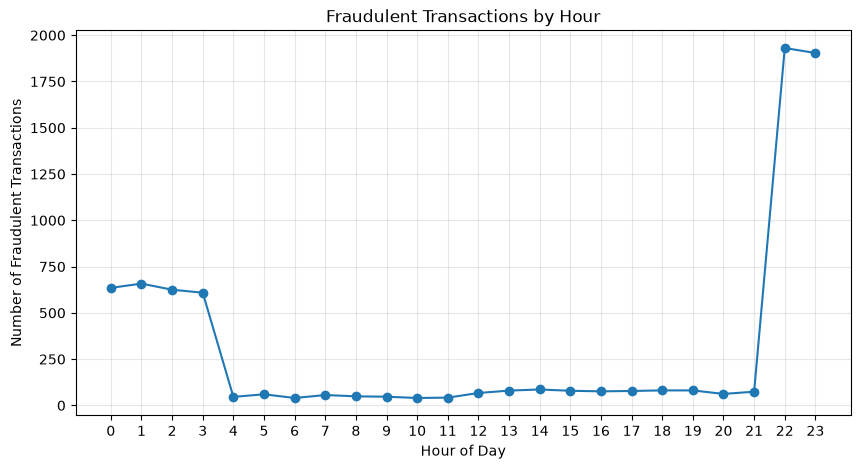

In [17]:
# ============================================================
# Step 17: Fraudulent Transactions by Hour
# ============================================================

fraud_by_hour = (
    train_df[train_df["is_fraud"] == 1]
    .groupby("transaction_hour")
    .size()
)

plt.figure(figsize=(10, 5))

plt.plot(
    fraud_by_hour.index,
    fraud_by_hour.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraudulent Transactions")
plt.title("Fraudulent Transactions by Hour")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

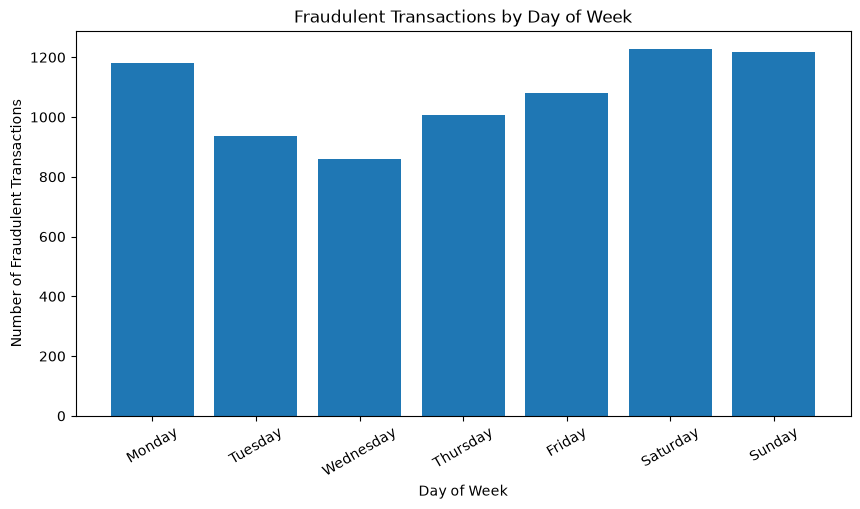

In [18]:
# ============================================================
# Step 18: Fraudulent Transactions by Day of Week
# ============================================================

fraud_by_day = (
    train_df[train_df["is_fraud"] == 1]
    .groupby("transaction_dayofweek")
    .size()
)

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10, 5))

plt.bar(
    [day_names[i] for i in fraud_by_day.index],
    fraud_by_day.values
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Fraudulent Transactions")
plt.title("Fraudulent Transactions by Day of Week")

plt.xticks(rotation=30)

plt.show()

In [19]:
# ============================================================
# Step 19: Fraud by Transaction Category
# ============================================================

category_fraud = pd.crosstab(
    train_df["category"],
    train_df["is_fraud"]
)

category_fraud.columns = [
    "Legitimate",
    "Fraudulent"
]

display(category_fraud.sort_values("Fraudulent", ascending=False))

,Legitimate,Fraudulent
category,,
grocery_pos,121895,1743
shopping_net,95830,1713
misc_net,62372,915
shopping_pos,115829,843
gas_transport,131041,618
misc_pos,79405,250
kids_pets,112796,239
entertainment,93781,233
personal_care,90538,220


In [20]:
# ============================================================
# Step 20: Fraud Rate by Category
# ============================================================

category_fraud_rate = (
    train_df.groupby("category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(
    category_fraud_rate.to_frame(
        name="Fraud Rate (%)"
    )
)

,Fraud Rate (%)
category,
shopping_net,1.756149
misc_net,1.445795
grocery_pos,1.409761
shopping_pos,0.722538
gas_transport,0.469394
misc_pos,0.313853
grocery_net,0.294817
travel,0.286370
entertainment,0.247835


In [21]:
# ============================================================
# Step 21: Check Duplicate Rows
# ============================================================

print("Training duplicates:", train_df.duplicated().sum())
print("Testing duplicates :", test_df.duplicated().sum())

Training duplicates: 0
Testing duplicates : 0


In [22]:
# ============================================================
# Step 22: Remove Unnecessary Columns
# ============================================================

for df in [train_df, test_df]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

print("Remaining columns:", len(train_df.columns))

Remaining columns: 26


In [23]:
# ============================================================
# Step 23: Customer Age Feature
# ============================================================

for df in [train_df, test_df]:
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    df["customer_age"] = (
        (df["trans_date_trans_time"] - df["dob"])
        .dt.days / 365.25
    )

    df["customer_age"] = df["customer_age"].round(1)

print(
    train_df[
        ["dob", "trans_date_trans_time", "customer_age"]
    ].head()
)

         dob trans_date_trans_time  customer_age
0 1988-03-09   2019-01-01 00:00:18          30.8
1 1978-06-21   2019-01-01 00:00:44          40.5
2 1962-01-19   2019-01-01 00:00:51          57.0
3 1967-01-12   2019-01-01 00:01:16          52.0
4 1986-03-28   2019-01-01 00:03:06          32.8


In [25]:
# ============================================================
# Step 24: Calculate Distance Between Customer and Merchant
# ============================================================

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two geographical coordinates.
    Result is approximately in kilometers.
    """

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    earth_radius = 6371

    return earth_radius * c
for df in [train_df, test_df]:

    df["distance_km"] = haversine_distance(
        df["lat"],
        df["long"],
        df["merch_lat"],
        df["merch_long"]
    )

print(
    train_df[
        ["lat", "long", "merch_lat", "merch_long", "distance_km"]
    ].head()
)

       lat      long  merch_lat  merch_long  distance_km
0  36.0788  -81.1781  36.011293  -82.048315    78.597568
1  48.8878 -118.2105  49.159047 -118.186462    30.212176
2  42.1808 -112.2620  43.150704 -112.154481   108.206083
3  46.2306 -112.1138  47.034331 -112.561071    95.673231
4  38.4207  -79.4629  38.674999  -78.632459    77.556744


In [26]:
# ============================================================
# Step 25: Distance Analysis
# ============================================================

distance_summary = train_df.groupby("is_fraud")["distance_km"].agg(
    ["mean", "median", "min", "max"]
)

distance_summary.index = [
    "Legitimate",
    "Fraudulent"
]

display(distance_summary)

,mean,median,min,max
Legitimate,76.113756,78.233012,0.022255,152.117173
Fraudulent,76.268330,77.931954,0.738769,144.522410


In [27]:
# ============================================================
# Step 26: Night Transaction Feature
# ============================================================

for df in [train_df, test_df]:

    df["is_night"] = (
        (df["transaction_hour"] < 6)
        | (df["transaction_hour"] >= 22)
    ).astype(int)

print(
    train_df[
        ["transaction_hour", "is_night"]
    ].head(10)
)

   transaction_hour  is_night
0                 0         1
1                 0         1
2                 0         1
3                 0         1
4                 0         1
5                 0         1
6                 0         1
7                 0         1
8                 0         1
9                 0         1


In [28]:
# ============================================================
# Step 27: Log Transform Transaction Amount
# ============================================================

for df in [train_df, test_df]:
    df["log_amt"] = np.log1p(df["amt"])

print(
    train_df[
        ["amt", "log_amt"]
    ].head()
)

      amt   log_amt
0    4.97  1.786747
1  107.23  4.684259
2  220.11  5.398660
3   45.00  3.828641
4   41.96  3.760269


In [29]:
# ============================================================
# Step 28: Feature Engineering Summary
# ============================================================

new_features = [
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "transaction_dayofweek",
    "customer_age",
    "distance_km",
    "is_night",
    "log_amt"
]

display(train_df[new_features].describe())

,transaction_hour,transaction_day,transaction_month,transaction_dayofweek,customer_age,distance_km,is_night,log_amt
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,1.280486e+01,1.558798e+01,6.142150e+00,3.070604e+00,4.599639e+01,7.611465e+01,2.999333e-01,3.533470e+00
std,6.817824e+00,8.829121e+00,3.417703e+00,2.198153e+00,1.739408e+01,2.911693e+01,4.582286e-01,1.289448e+00
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.390000e+01,2.225452e-02,0.000000e+00,6.931472e-01
25%,7.000000e+00,8.000000e+00,3.000000e+00,1.000000e+00,3.260000e+01,5.533491e+01,0.000000e+00,2.365560e+00
50%,1.400000e+01,1.500000e+01,6.000000e+00,3.000000e+00,4.400000e+01,7.823175e+01,0.000000e+00,3.881976e+00
75%,1.900000e+01,2.300000e+01,9.000000e+00,5.000000e+00,5.710000e+01,9.850327e+01,1.000000e+00,4.432482e+00
max,2.300000e+01,3.100000e+01,1.200000e+01,6.000000e+00,9.560000e+01,1.521172e+02,1.000000e+00,1.027332e+01


In [30]:
# ============================================================
# Step 29: Remove Raw / Unnecessary Features
# ============================================================

columns_to_drop = [
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "city",
    "state",
    "zip",
    "job",
    "unix_time",
    "cc_num"
]

train_df = train_df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

test_df = test_df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

Training shape: (1296675, 19)
Testing shape : (555719, 19)


In [31]:
# ============================================================
# Step 30: Separate Features and Target
# ============================================================

X_train = train_df.drop(columns=["is_fraud"])
y_train = train_df["is_fraud"]

X_test = test_df.drop(columns=["is_fraud"])
y_test = test_df["is_fraud"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (1296675, 18)
y_train: (1296675,)

X_test : (555719, 18)
y_test : (555719,)


In [32]:
# ============================================================
# Step 31: Identify Categorical and Numerical Features
# ============================================================

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['merchant', 'category', 'gender', 'trans_num']

Numerical features:
['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_dayofweek', 'customer_age', 'distance_km', 'is_night', 'log_amt']


In [33]:
# ============================================================
# Step 32: Preprocessing Pipeline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Numerical features
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Categorical features
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

# Combine both transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [34]:
# ============================================================
# Step 33: Logistic Regression Pipeline
# ============================================================

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [35]:
# ============================================================
# Step 34: Train Logistic Regression
# ============================================================

print("Training Logistic Regression...")
print("This may take some time because the dataset is large.\n")

logistic_model.fit(X_train, y_train)

print("Training completed successfully! ✅")

Training Logistic Regression...
This may take some time because the dataset is large.

Training completed successfully! ✅


In [36]:
# ============================================================
# Step 35: Make Predictions
# ============================================================

y_pred_lr = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_lr))

Predictions generated successfully!
Number of predictions: 555719


In [37]:
# ============================================================
# Step 36: Logistic Regression Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy : 0.9934
Precision: 0.3043
Recall   : 0.5431
F1 Score : 0.3901

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.30      0.54      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.77      0.69    555719
weighted avg       1.00      0.99      0.99    555719



Confusion Matrix:
[[550911   2663]
 [   980   1165]]


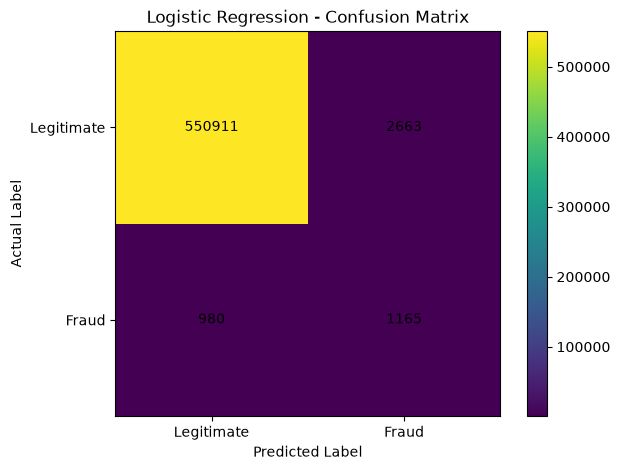

In [39]:
# ============================================================
# Step 37: Confusion Matrix
# ============================================================

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

plt.figure(figsize=(7, 5))

plt.imshow(cm_lr)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_lr[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [40]:
# ============================================================
# Step 39: Store Logistic Regression Results
# ============================================================

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1 Score": f1_lr
})

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.993445,0.304336,0.543124,0.390089


In [44]:
# ============================================================
# Step 40: Decision Tree Classifier
# ============================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                class_weight="balanced",
                max_depth=12,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

print("Decision Tree pipeline created successfully! ✅")

Decision Tree pipeline created successfully! ✅


In [45]:
# ============================================================
# Step 41: Train Decision Tree
# ============================================================

print("Training Decision Tree...")
print("This may take some time.\n")

decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed! ✅")

Training Decision Tree...
This may take some time.

Decision Tree training completed! ✅


In [46]:
# ============================================================
# Step 42: Decision Tree Predictions
# ============================================================

y_pred_dt = decision_tree_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_dt))

Predictions generated successfully!
Number of predictions: 555719


In [47]:
# ============================================================
# Step 43: Decision Tree Evaluation
# ============================================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("DECISION TREE RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

DECISION TREE RESULTS
Accuracy : 0.9706
Precision: 0.1120
Recall   : 0.9562
F1 Score : 0.2004

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.11      0.96      0.20      2145

    accuracy                           0.97    555719
   macro avg       0.56      0.96      0.59    555719
weighted avg       1.00      0.97      0.98    555719



Confusion Matrix:
[[537306  16268]
 [    94   2051]]


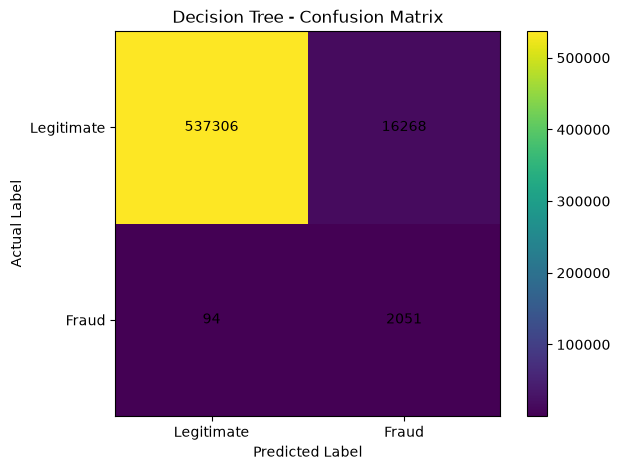

In [48]:
# ============================================================
# Step 44: Decision Tree Confusion Matrix
# ============================================================

cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

plt.figure(figsize=(7, 5))

plt.imshow(cm_dt)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_dt[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [49]:
# ============================================================
# Step 45: Store Decision Tree Results
# ============================================================

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_dt,
    "Precision": precision_dt,
    "Recall": recall_dt,
    "F1 Score": f1_dt
})

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9934,0.3043,0.5431,0.3901
1,Decision Tree,0.9706,0.1120,0.9562,0.2004


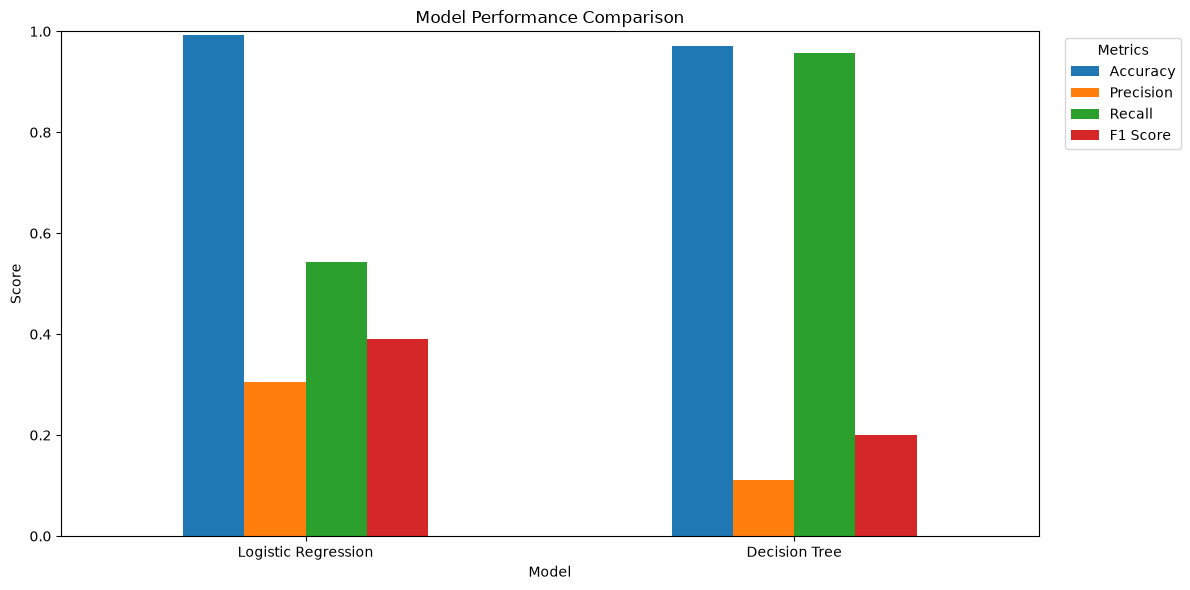

In [50]:
# ============================================================
# Step 46: Current Model Comparison
# ============================================================

comparison = results_df.set_index("Model")

comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [51]:
# ============================================================
# Step 47: Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=15,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully! ✅")

Random Forest pipeline created successfully! ✅


In [52]:
# ============================================================
# Step 48: Train Random Forest
# ============================================================

print("Training Random Forest...")
print("This can take several minutes because the dataset is large.\n")

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed! ✅")

Training Random Forest...
This can take several minutes because the dataset is large.

Random Forest training completed! ✅


In [53]:
# ============================================================
# Step 49: Random Forest Predictions
# ============================================================

y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated successfully! ✅")
print("Number of predictions:", len(y_pred_rf))

Predictions generated successfully! ✅
Number of predictions: 555719


In [54]:
# ============================================================
# Step 50: Random Forest Evaluation
# ============================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("RANDOM FOREST RESULTS")
print("=" * 50)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy : 0.8999
Precision: 0.0109
Recall   : 0.2783
F1 Score : 0.0210

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    553574
           1       0.01      0.28      0.02      2145

    accuracy                           0.90    555719
   macro avg       0.50      0.59      0.48    555719
weighted avg       0.99      0.90      0.94    555719



Confusion Matrix:
[[499498  54076]
 [  1548    597]]


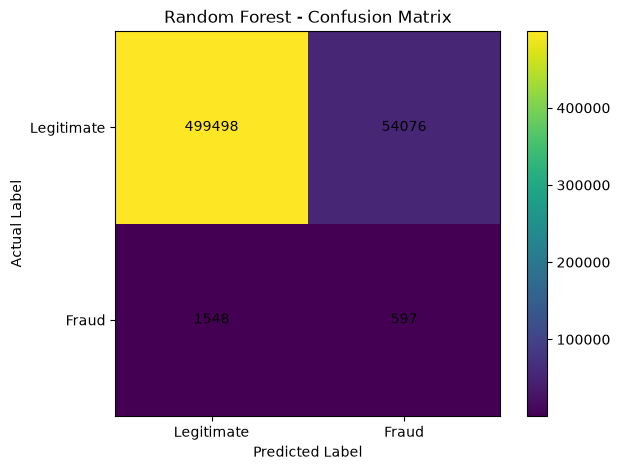

In [55]:
# ============================================================
# Step 51: Random Forest Confusion Matrix
# ============================================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(7, 5))

plt.imshow(cm_rf)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [56]:
# ============================================================
# Step 52: Store Random Forest Results
# ============================================================

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1 Score": f1_rf
})

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9934,0.3043,0.5431,0.3901
1,Decision Tree,0.9706,0.1120,0.9562,0.2004
2,Random Forest,0.8999,0.0109,0.2783,0.0210


In [57]:
# ============================================================
# Step 53: Final Model Comparison
# ============================================================

print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.993445,0.304336,0.543124,0.390089
1,Decision Tree,0.970557,0.111960,0.956177,0.200450
2,Random Forest,0.899906,0.010919,0.278322,0.021014


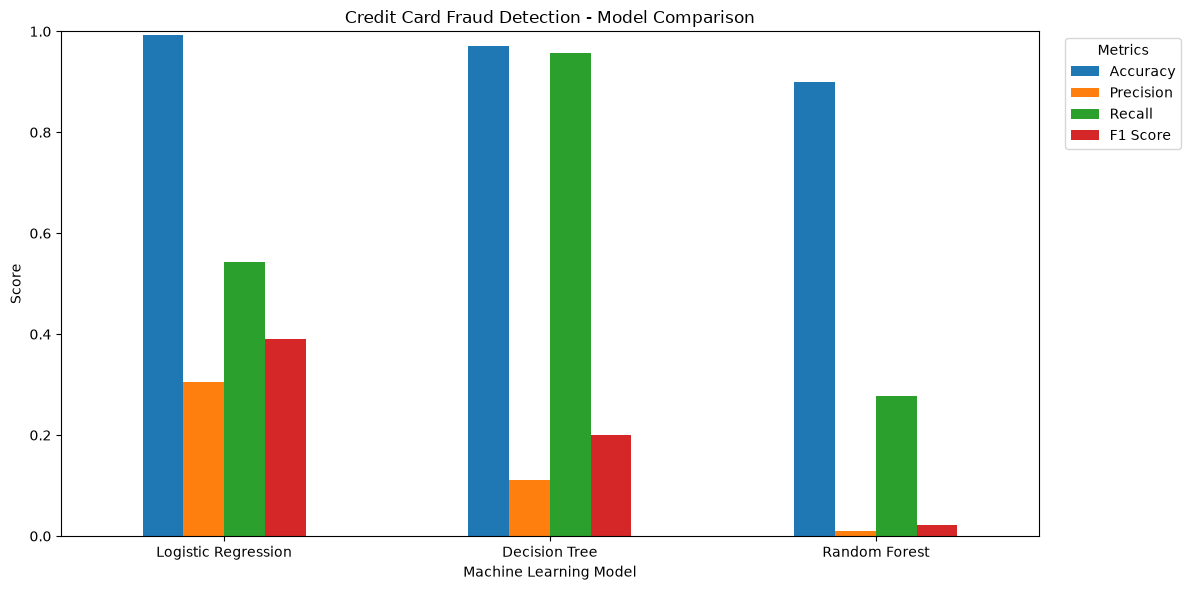

In [58]:
# ============================================================
# Step 54: Compare Model Metrics
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

comparison = results_df.set_index("Model")[metrics]

ax = comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Credit Card Fraud Detection - Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [59]:
# ============================================================
# Step 55: Select Best Model
# ============================================================

best_model_name = (
    results_df.loc[
        results_df["F1 Score"].idxmax(),
        "Model"
    ]
)

best_f1_score = (
    results_df["F1 Score"].max()
)

print("BEST MODEL")
print("=" * 50)
print("Model   :", best_model_name)
print("F1 Score:", f"{best_f1_score:.4f}")

BEST MODEL
Model   : Logistic Regression
F1 Score: 0.3901


In [60]:
# ============================================================
# Step 56: ROC-AUC Scores
# ============================================================

from sklearn.metrics import roc_auc_score

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

roc_lr = roc_auc_score(y_test, y_prob_lr)
roc_dt = roc_auc_score(y_test, y_prob_dt)
roc_rf = roc_auc_score(y_test, y_prob_rf)

roc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "ROC-AUC": [
        roc_lr,
        roc_dt,
        roc_rf
    ]
})

display(
    roc_results.style.format({
        "ROC-AUC": "{:.4f}"
    })
)

,Model,ROC-AUC
0,Logistic Regression,0.9322
1,Decision Tree,0.9697
2,Random Forest,0.6149


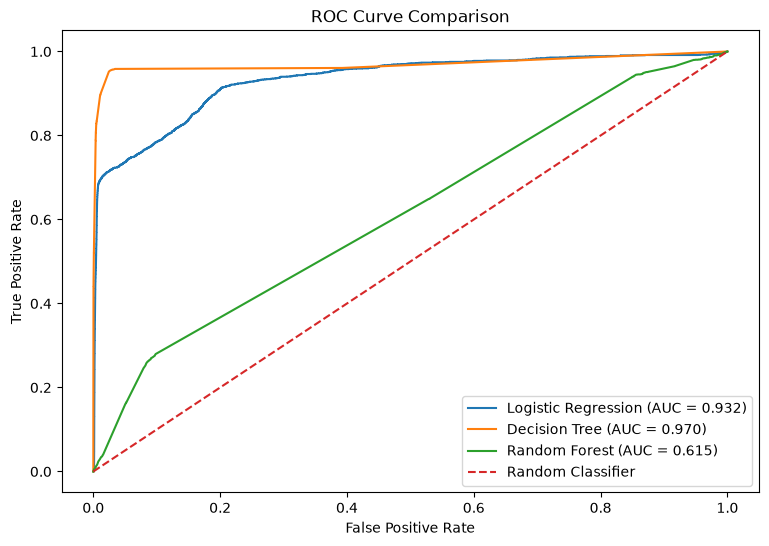

In [61]:
# ============================================================
# Step 57: ROC Curve
# ============================================================

from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_lr:.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_dt:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [62]:
# ============================================================
# Step 58: Precision-Recall Curve Comparison
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_lr_curve, recall_lr_curve, _ = precision_recall_curve(
    y_test, y_prob_lr
)

precision_dt_curve, recall_dt_curve, _ = precision_recall_curve(
    y_test, y_prob_dt
)

precision_rf_curve, recall_rf_curve, _ = precision_recall_curve(
    y_test, y_prob_rf
)

ap_lr = average_precision_score(y_test, y_prob_lr)
ap_dt = average_precision_score(y_test, y_prob_dt)
ap_rf = average_precision_score(y_test, y_prob_rf)

print("Average Precision Scores")
print("=" * 50)
print(f"Logistic Regression: {ap_lr:.4f}")
print(f"Decision Tree      : {ap_dt:.4f}")
print(f"Random Forest      : {ap_rf:.4f}")

Average Precision Scores
Logistic Regression: 0.2107
Decision Tree      : 0.6156
Random Forest      : 0.0066


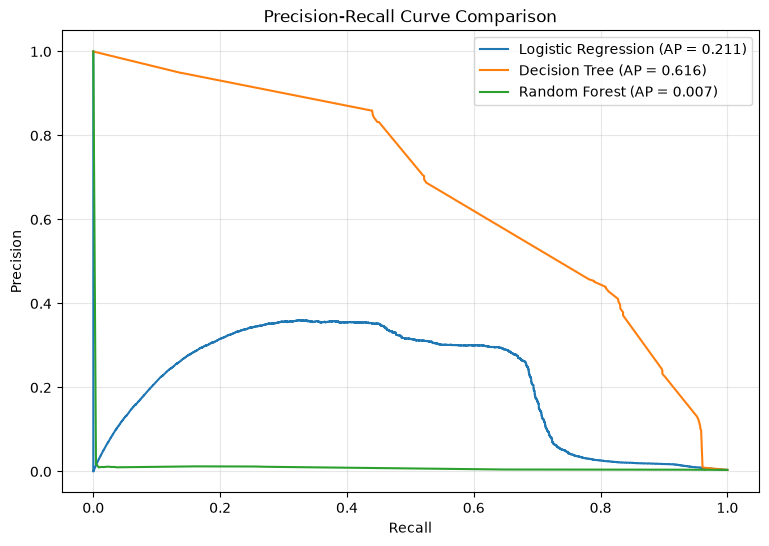

In [63]:
# ============================================================
# Step 59: Precision-Recall Curves
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    recall_lr_curve,
    precision_lr_curve,
    label=f"Logistic Regression (AP = {ap_lr:.3f})"
)

plt.plot(
    recall_dt_curve,
    precision_dt_curve,
    label=f"Decision Tree (AP = {ap_dt:.3f})"
)

plt.plot(
    recall_rf_curve,
    precision_rf_curve,
    label=f"Random Forest (AP = {ap_rf:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

In [64]:
# ============================================================
# Step 60: Complete Model Comparison
# ============================================================

final_comparison = results_df.copy()

final_comparison["ROC-AUC"] = [
    roc_lr,
    roc_dt,
    roc_rf
]

final_comparison["Average Precision"] = [
    ap_lr,
    ap_dt,
    ap_rf
]

final_comparison = final_comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    final_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Logistic Regression,0.9934,0.3043,0.5431,0.3901,0.9322,0.2107
1,Decision Tree,0.9706,0.1120,0.9562,0.2004,0.9697,0.6156
2,Random Forest,0.8999,0.0109,0.2783,0.0210,0.6149,0.0066


In [65]:
# ============================================================
# Step 61: Final Model Selection
# ============================================================

best_row = final_comparison.iloc[0]

print("🏆 FINAL MODEL")
print("=" * 50)

print("Model:", best_row["Model"])
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1 Score: {best_row['F1 Score']:.4f}")
print(f"ROC-AUC: {best_row['ROC-AUC']:.4f}")
print(f"Average Precision: {best_row['Average Precision']:.4f}")

🏆 FINAL MODEL
Model: Logistic Regression
Accuracy: 0.9934
Precision: 0.3043
Recall: 0.5431
F1 Score: 0.3901
ROC-AUC: 0.9322
Average Precision: 0.2107


In [66]:
# ============================================================
# Step 62: Save Best Model
# ============================================================

import joblib
import os

os.makedirs("../models", exist_ok=True)

model_mapping = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

best_model = model_mapping[best_row["Model"]]

MODEL_PATH = "../models/fraud_detection_model.pkl"

joblib.dump(best_model, MODEL_PATH)

print("Best model saved successfully! ✅")
print("Location:", MODEL_PATH)

Best model saved successfully! ✅
Location: ../models/fraud_detection_model.pkl


In [69]:
# ============================================================
# Step 63: Load Saved Model
# ============================================================

loaded_model = joblib.load(MODEL_PATH)

test_predictions = loaded_model.predict(X_test)

print("Saved model loaded successfully! ✅")
print("Predictions generated:", len(test_predictions))

print(
    "Predictions identical:",
    np.array_equal(y_pred_rf, test_predictions)
)

saved_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(f"Saved model accuracy: {saved_accuracy:.4f}")

Saved model loaded successfully! ✅
Predictions generated: 555719
Predictions identical: False
Saved model accuracy: 0.9934


In [70]:
# ============================================================
# Step 64: Save Model Comparison
# ============================================================

os.makedirs("../results", exist_ok=True)

results_path = "../results/model_comparison.csv"

final_comparison.to_csv(
    results_path,
    index=False
)

print("Model comparison saved successfully! ✅")
print("Location:", results_path)

Model comparison saved successfully! ✅
Location: ../results/model_comparison.csv


In [71]:
# ============================================================
# Step 65: Save Feature Information
# ============================================================

feature_info = {
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "new_features": new_features,
    "dropped_features": columns_to_drop
}

joblib.dump(
    feature_info,
    "../models/feature_info.pkl"
)

print("Feature information saved successfully! ✅")

Feature information saved successfully! ✅
